# 2.1 Unsupervised Learning Algorithms with reduced data

## 01 Load Libraries & Dataset (with PCA reduced data)
## 02 Filtering & Wrangling
## 03 Dendrograms (with reduced data)
## 04 Insights

### 01 Load Libraries & Dataset (with PCA reduced data)

In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [5]:
# Create a path for the import of dataset

path = r'C:\Users\wallm\02 2025 Machine Learning Project\02 Data'

In [45]:
# Import weather dataset

climate = pd.read_csv(os.path.join(path, '02 Prepared Data', '2010_PCA.csv'))

In [47]:
climate.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-14.637266,2.443633,-6.587953,5.879753,1.287782,-2.892771,-0.966803,-4.191464,2.556764,0.804381
1,-14.472253,3.727368,-8.395420,7.412833,5.734935,-2.273606,-1.451451,-7.049814,4.883152,3.543863
2,-14.044808,2.113257,-7.237470,4.824640,4.256978,-1.496644,-3.319999,-1.674158,3.582551,0.818561
3,-11.597381,0.959781,-6.926106,3.362258,3.953786,-4.625995,0.228261,-2.149960,2.390329,4.411747
4,-8.904840,0.120644,-6.657080,2.499185,-0.161643,-4.715468,2.377175,1.594747,2.848863,2.575002


In [36]:
# Import the 'Pleasant weather' dataset

pleasantweather = pd.read_csv(os.path.join(path, '01 Original Data', 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [38]:
pleasantweather.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### 02 Filtering & Wrangling

In [49]:
climate.isnull().sum()

PC1     0
PC2     0
PC3     0
PC4     0
PC5     0
PC6     0
PC7     0
PC8     0
PC9     0
PC10    0
dtype: int64

## 03 Dendrograms (with reduced data)

In [53]:
X_all_stations = climate.copy()  # retitle df to re-use clustering codes from previous script

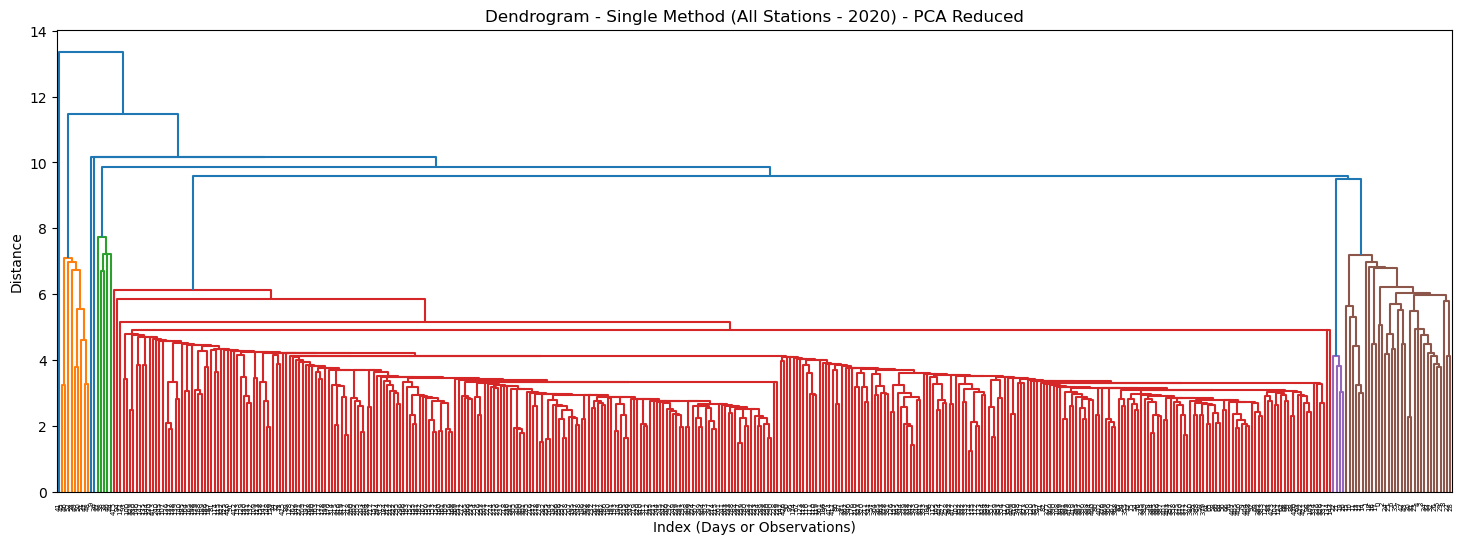

In [63]:
# Single linkage method for all stations
distance1 = linkage(X_all_stations, method='single')

plt.figure(figsize=(18, 6))
dendrogram(distance1, leaf_rotation=90)
plt.title("Dendrogram - Single Method (All Stations - 2020) - PCA Reduced")
plt.xlabel("Index (Days or Observations)")
plt.ylabel("Distance")
plt.show()

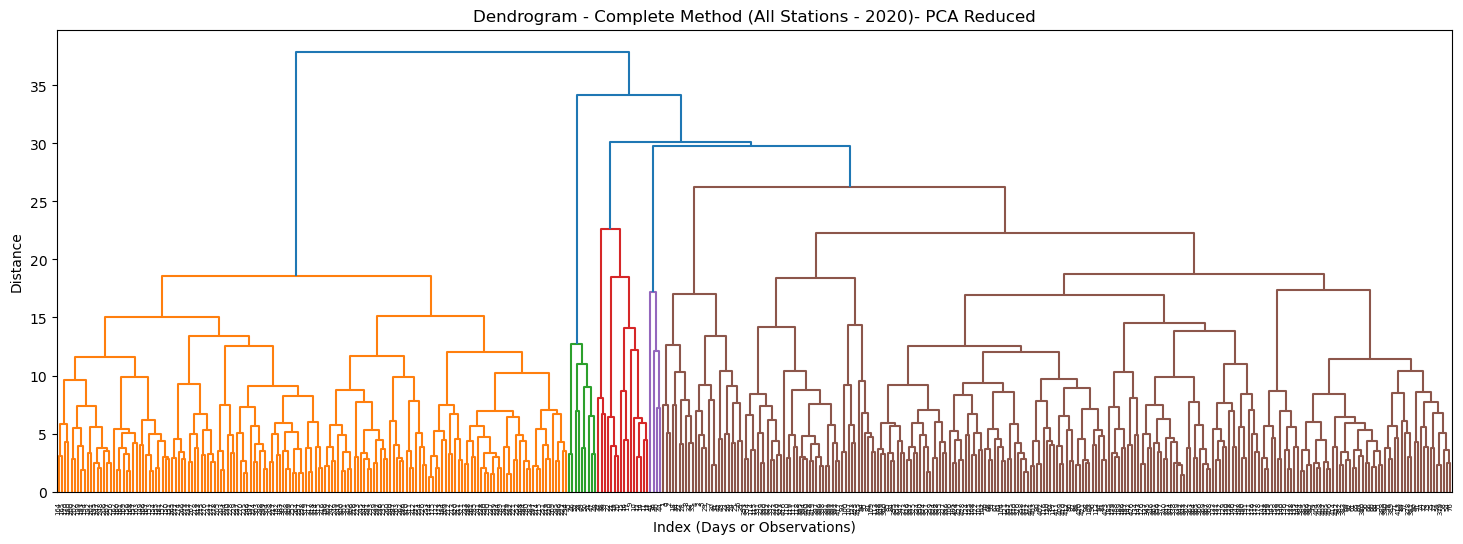

In [65]:
# Complete linkage method for all stations
distance1 = linkage(X_all_stations, method='complete')

plt.figure(figsize=(18, 6))
dendrogram(distance1, leaf_rotation=90)
plt.title("Dendrogram - Complete Method (All Stations - 2020)- PCA Reduced")
plt.xlabel("Index (Days or Observations)")
plt.ylabel("Distance")
plt.show()

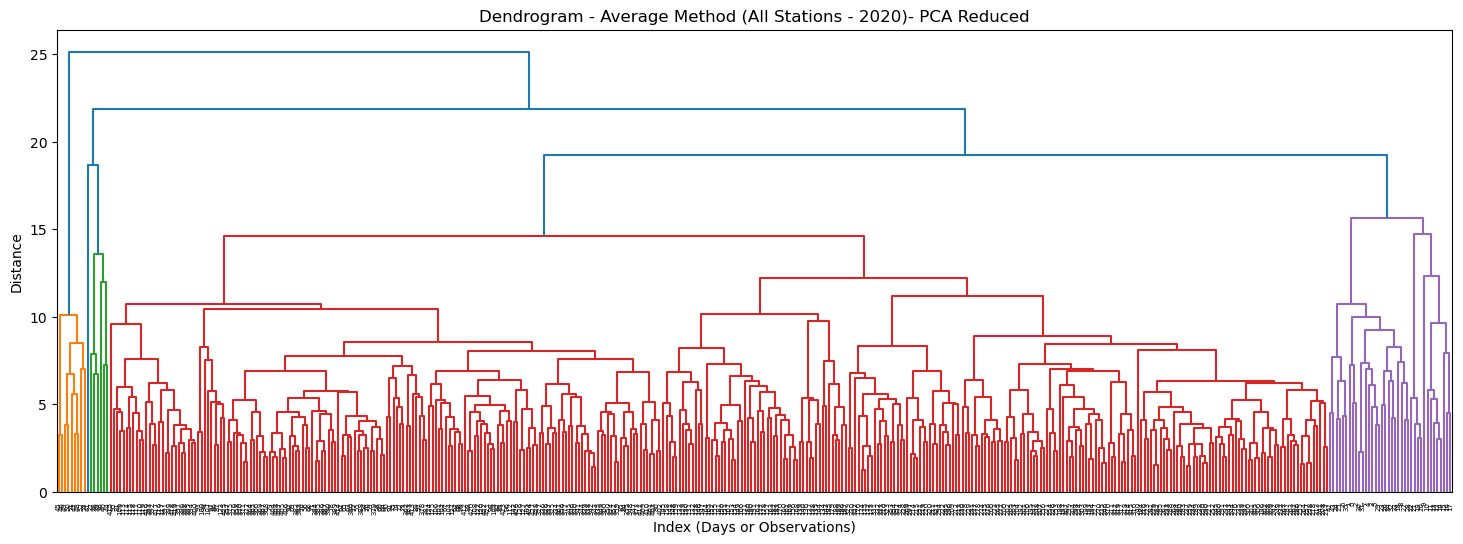

In [67]:
# Average linkage method for all stations
distance1 = linkage(X_all_stations, method='average')

plt.figure(figsize=(18, 6))
dendrogram(distance1, leaf_rotation=90)
plt.title("Dendrogram - Average Method (All Stations - 2020)- PCA Reduced")
plt.xlabel("Index (Days or Observations)")
plt.ylabel("Distance")
plt.show()

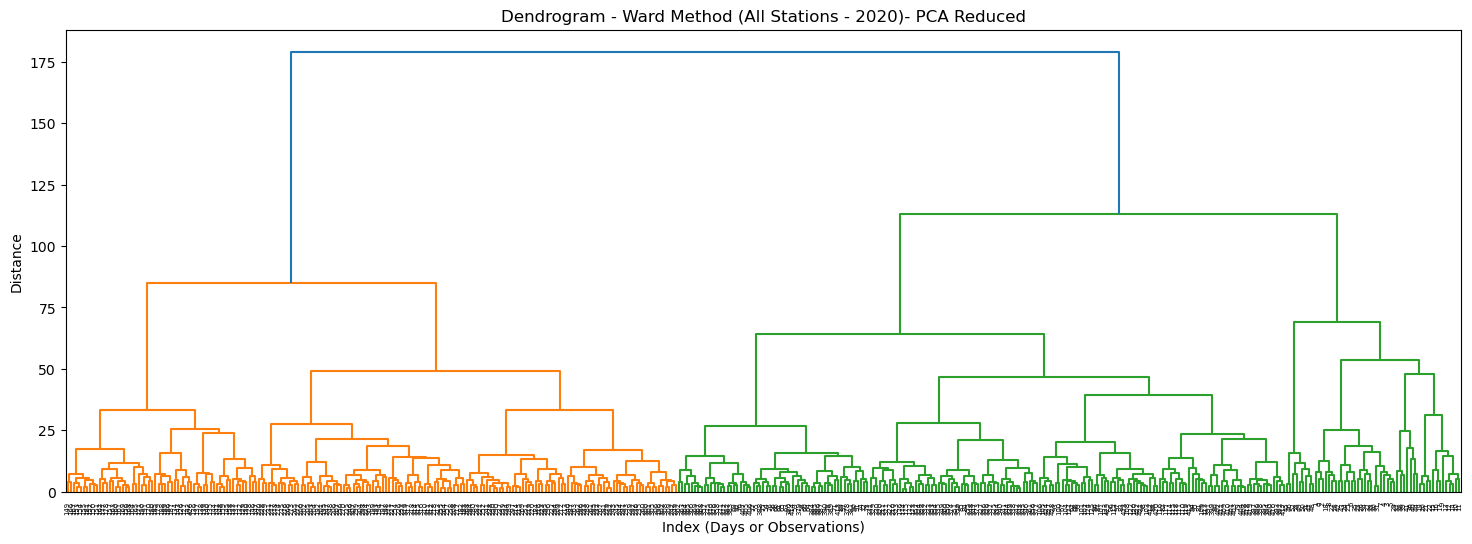

In [69]:
# Ward linkage method for all stations
distance1 = linkage(X_all_stations, method='ward')

plt.figure(figsize=(18, 6))
dendrogram(distance1, leaf_rotation=90)
plt.title("Dendrogram - Ward Method (All Stations - 2020)- PCA Reduced")
plt.xlabel("Index (Days or Observations)")
plt.ylabel("Distance")
plt.show()

## 04 Insights

### Insights from Dendrograms (Using PCA-Reduced Data – All Stations, 2020)

- Single Method: Still not very useful — most of the data ends up in one long chain again. Even after simplifying the dataset, this method doesn’t help us see clear groups.
  
- Complete Method: This method gives us 4–5 clearer groups. It works even better with the simplified data and seems to notice patterns based on where stations are (like near the sea or in the mountains).

- Average Method: Shows 2–3 general groups. Similar to the full data version, but slightly cleaner. It captures big-picture weather trends, but not smaller differences.

- Ward Method: Again, this is the most useful. It splits the data into 3 clear, balanced groups — probably showing different types of climates (like coastal, inland, or high-altitude areas). Reducing the data with PCA made the clusters even clearer and easier to interpret.

### Conclusion:
- **Ward is still the best method**, and now it runs faster and gives even clearer results thanks to PCA.
- **Simplifying the data with PCA kept the important patterns** but removed extra detail that wasn't helping, making clustering more effective.
